In [1]:
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
from functools import lru_cache
from itertools import islice
import numpy as np
import json

In [2]:
Pose = Dict[str, List[float]]
Move = Dict[float, Pose]

In [15]:
bones = (
    ("LEFT_WRIST", "LEFT_ELBOW"),
    ("LEFT_ELBOW", "LEFT_SHOULDER"),
    ("RIGHT_WRIST", "RIGHT_ELBOW"),
    ("RIGHT_ELBOW", "RIGHT_SHOULDER"),
    ("LEFT_SHOULDER", "RIGHT_SHOULDER"),
    ("LEFT_SHOULDER", "LEFT_HIP"),
    ("RIGHT_SHOULDER", "RIGHT_HIP"),
    ("LEFT_HIP", "RIGHT_HIP"),
    ("LEFT_HIP", "LEFT_KNEE"),
    ("LEFT_KNEE", "LEFT_ANKLE"),
    ("RIGHT_HIP", "RIGHT_KNEE"),
    ("RIGHT_KNEE", "RIGHT_ANKLE"),
)

landmarks = [
    f"{side}_{bodypart}"
    for side in ["LEFT", "RIGHT"]
    for bodypart in ["WRIST", "ELBOW", "SHOULDER", "HIP", "KNEE", "ANKLE"]
]

In [16]:
lerp = lambda x, y, t: np.array(x) + t * (np.array(y) - np.array(x))
normalize = lambda x: x / np.linalg.norm(x)
norm_diff = lambda x, y: (y - x) / np.linalg.norm(y - x)
rescale = lambda x, l, u: np.clip(1 - ((x - u) / (l - u)), 0, 1)

def cosine_similarity(a, b):
    return (np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)) + 1) / 2

In [27]:
def lerp_frames(pose1: Pose, pose2: Pose, frac: float) -> Pose:
    return {lm: lerp(pose1[lm], pose2[lm], frac) for lm in landmarks}

In [28]:
def fill_values(move1: Move, move2: Move) -> Tuple[Move, Move]:
    zero = lambda move: {time - list(move)[0]: move[time] for time in move}
    move1, move2 = zero(move1), zero(move2)

    all_times = np.sort(np.unique(np.concatenate([list(move1), list(move2)])))
    frac = lambda arr, x, i: (x - arr[i - 1]) / (arr[i] - arr[i - 1])

    def fill(move):
        times, poses = list(move.keys()), list(move.values())
        out, p = {}, 0

        for time in all_times:
            if time in times:
                out[time] = poses[p]
                p += p < len(poses) - 1
            else:
                out[time] = lerp_frames(poses[p - 1], poses[p], frac(times, time, p))
        return out

    return fill(move1), fill(move2)

In [29]:
def calculate_similarities(pose1: Pose, pose2: Pose) -> List[float]:
    sub = lambda x, y: np.array(x) - np.array(y)
    return [
        cosine_similarity(sub(pose1[j1], pose1[j2]), sub(pose2[j1], pose2[j2]))
        for j1, j2 in bones
    ]


def similarity_score(move1: Move, move2: Move) -> float:
    similarities = [
        calculate_similarities(list(move1.values())[i], list(move2.values())[i])
        for i in range(len(move1))
    ]
    return np.mean(similarities)

In [30]:
def score(move1: Move, move2: Move) -> float:
    if len(move1) > len(move2):
        move1, move2 = move2, move1

    window = lambda i: dict(islice(move2.items(), i - len(move1), i))
    return [
        rescale(similarity_score(*fill_values(move1, window(i))), 0, 1)
        for i in range(len(move1), len(move2) + 1)
    ]

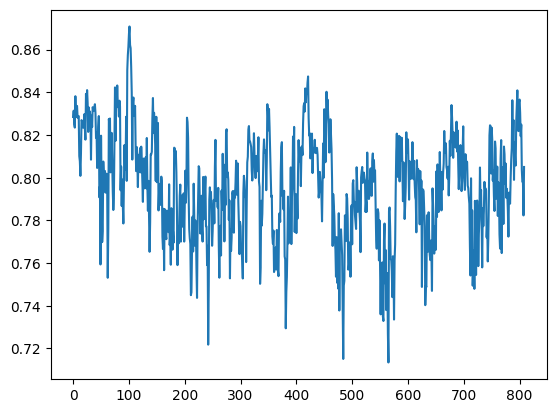

In [31]:
with open('../Data/Test/deadpool.json', 'r') as f:
    deadpool = {pose['timestamp']: pose['landmarks'] for pose in json.load(f)}
    
with open('../Data/Test/anu.json', 'r') as f:
    anu = {pose['timestamp']: pose['landmarks'] for pose in json.load(f)}
    
dslice = lambda d, s, e: dict(islice(d.items(), s, e))
plt.plot(score(anu, deadpool))